In [19]:
import pandas as pd
import numpy as np

df = pd.read_csv('../data/raw/Telco-Customer-Churn.csv')

In [20]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [21]:
df.shape

(7043, 21)

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [23]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [24]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [25]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [26]:
df['Churn'].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

In [28]:
df.isnull().sum().sort_values(ascending=False)

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [30]:
(df.isnull().sum() / len(df)) * 100

customerID          0.0
gender              0.0
SeniorCitizen       0.0
Partner             0.0
Dependents          0.0
tenure              0.0
PhoneService        0.0
MultipleLines       0.0
InternetService     0.0
OnlineSecurity      0.0
OnlineBackup        0.0
DeviceProtection    0.0
TechSupport         0.0
StreamingTV         0.0
StreamingMovies     0.0
Contract            0.0
PaperlessBilling    0.0
PaymentMethod       0.0
MonthlyCharges      0.0
TotalCharges        0.0
Churn               0.0
dtype: float64

In [31]:
# Number of duplicate rows
df.duplicated().sum()

np.int64(0)

In [32]:
df["customerID"].duplicated().sum()

np.int64(0)

In [34]:
df.nunique().sort_values()

gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
PhoneService           2
PaperlessBilling       2
Churn                  2
MultipleLines          3
TechSupport            3
StreamingTV            3
OnlineBackup           3
DeviceProtection       3
StreamingMovies        3
Contract               3
OnlineSecurity         3
InternetService        3
PaymentMethod          4
tenure                73
MonthlyCharges      1585
TotalCharges        6531
customerID          7043
dtype: int64

In [35]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [37]:
numeric_features = df.select_dtypes(include="number").columns

numeric_features

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges'], dtype='object')

In [38]:
categorical_features = df.select_dtypes(include="object").columns

categorical_features

Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges',
       'Churn'],
      dtype='object')

In [39]:
# Finding Unexpected values, spelling issues, blank strings etc
for col in categorical_features:
    print(f"\n{col}:")
    print(df[col].unique())


customerID:
['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']

gender:
['Female' 'Male']

Partner:
['Yes' 'No']

Dependents:
['No' 'Yes']

PhoneService:
['No' 'Yes']

MultipleLines:
['No phone service' 'No' 'Yes']

InternetService:
['DSL' 'Fiber optic' 'No']

OnlineSecurity:
['No' 'Yes' 'No internet service']

OnlineBackup:
['Yes' 'No' 'No internet service']

DeviceProtection:
['No' 'Yes' 'No internet service']

TechSupport:
['No' 'Yes' 'No internet service']

StreamingTV:
['No' 'Yes' 'No internet service']

StreamingMovies:
['No' 'Yes' 'No internet service']

Contract:
['Month-to-month' 'One year' 'Two year']

PaperlessBilling:
['Yes' 'No']

PaymentMethod:
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']

TotalCharges:
['29.85' '1889.5' '108.15' ... '346.45' '306.6' '6844.5']

Churn:
['No' 'Yes']


In [40]:
df = df.drop(columns="customerID")

In [41]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [42]:
df.isnull().sum().sort_values(ascending=False)

TotalCharges        11
gender               0
Partner              0
SeniorCitizen        0
Dependents           0
tenure               0
MultipleLines        0
PhoneService         0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
InternetService      0
TechSupport          0
StreamingTV          0
Contract             0
StreamingMovies      0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
Churn                0
dtype: int64

In [43]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [44]:
df["TotalCharges"].isnull().sum()

np.int64(11)

In [45]:
df = df.dropna()

In [48]:
df.duplicated().sum()

np.int64(22)

In [49]:
df = df.drop_duplicates()

In [50]:
df["Churn"] = df["Churn"].map({
    "Yes": 1,
    "No": 0
})

In [51]:
df["Churn"].value_counts()

Churn
0    5153
1    1857
Name: count, dtype: int64

In [52]:
df.shape

(7010, 20)

In [53]:
df.isnull().sum().sum()

np.int64(0)

In [54]:
df.dtypes

gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object

<h1 style="color:orange; font-weight:bold">Step 5 — EDA</h1>


<h5 style="color:white; font-weight:bold">5.1 → Target Analysis</h5>
<h5 style="color:white; font-weight:bold">5.2 → Numerical Features</h5>
<h5 style="color:white; font-weight:bold">5.3 → Categorical Features</h5>
<h5 style="color:white; font-weight:bold">5.4 → Relationship with Churn</h5>

In [55]:
df["Churn"].value_counts()

Churn
0    5153
1    1857
Name: count, dtype: int64

In [56]:
df['Churn'].value_counts(normalize=True) * 100

Churn
0    73.509272
1    26.490728
Name: proportion, dtype: float64

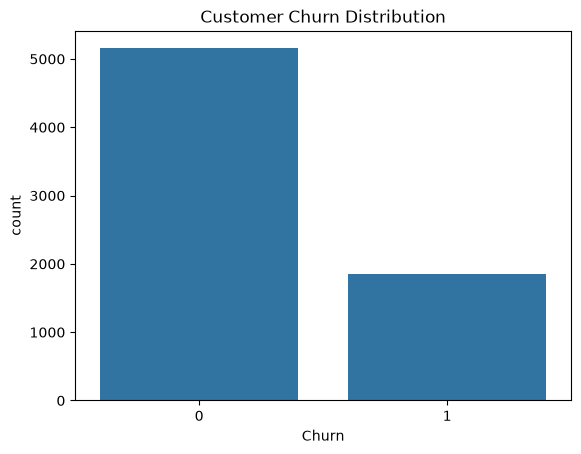

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")
plt.show()

In [60]:
numeric_features = df.select_dtypes(include='number').columns
numeric_features

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn'], dtype='object')

In [61]:
df[numeric_features].describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7010.0,0.162767,0.369180,0.00,0.0000,0.000,0.0000,1.00
tenure,7010.0,32.520399,24.520441,1.00,9.0000,29.000,56.0000,72.00
MonthlyCharges,7010.0,64.888666,30.064769,18.25,35.7500,70.400,89.9000,118.75
TotalCharges,7010.0,2290.353388,2266.820832,18.80,408.3125,1403.875,3807.8375,8684.80
Churn,7010.0,0.264907,0.441315,0.00,0.0000,0.000,1.0000,1.00


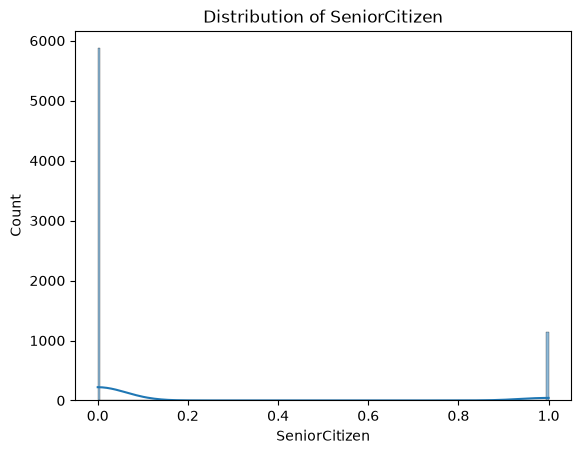

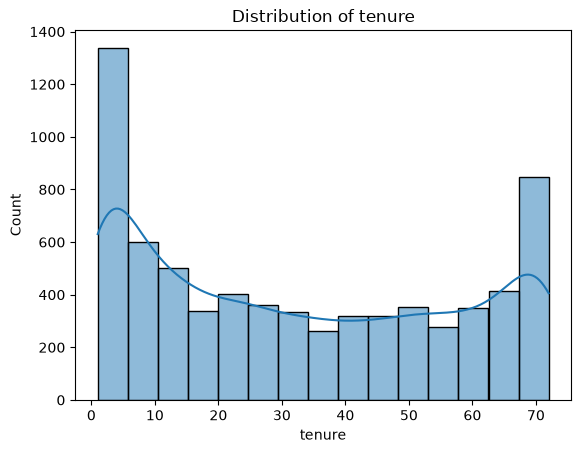

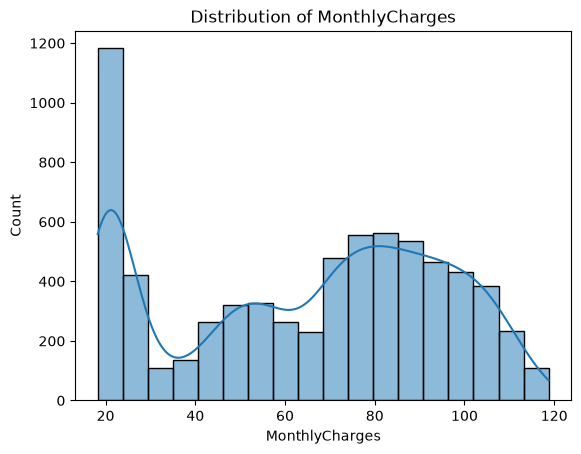

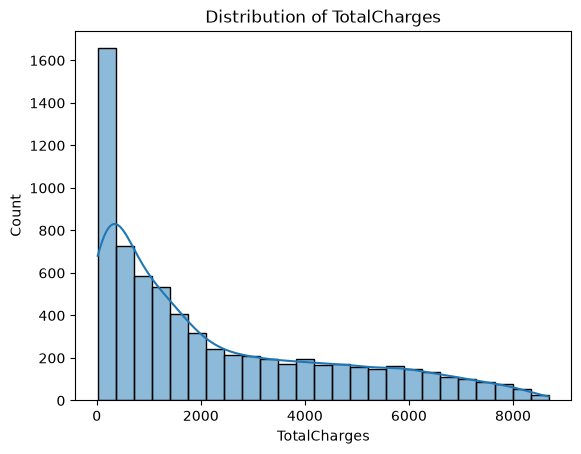

In [62]:
for col in numeric_features:
    if col != "Churn":
        sns.histplot(data=df, x=col, kde=True)
        plt.title(f"Distribution of {col}")
        plt.show()

In [63]:
categorical_features = df.select_dtypes(include='object').columns
categorical_features

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

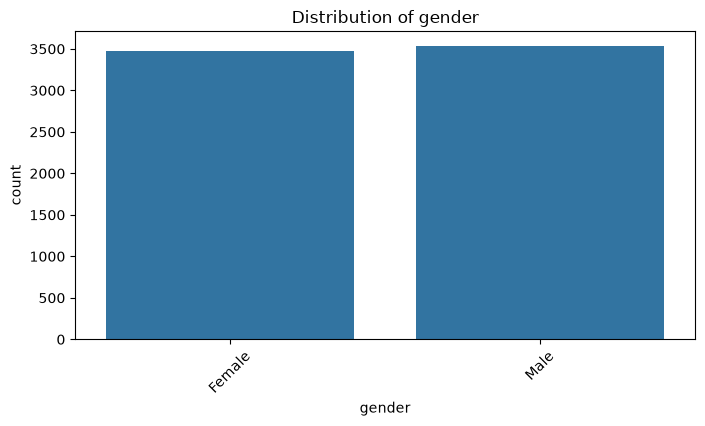

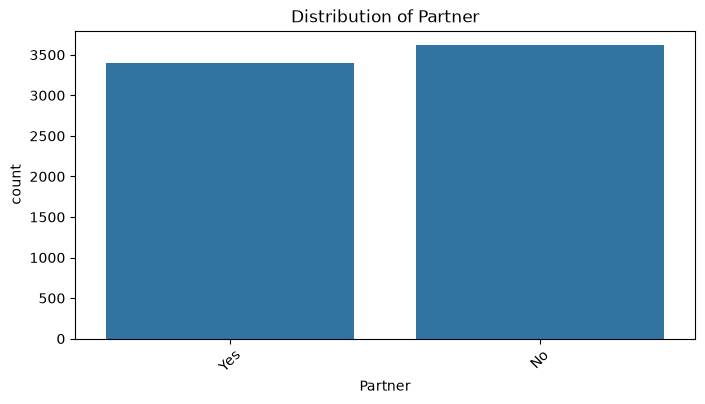

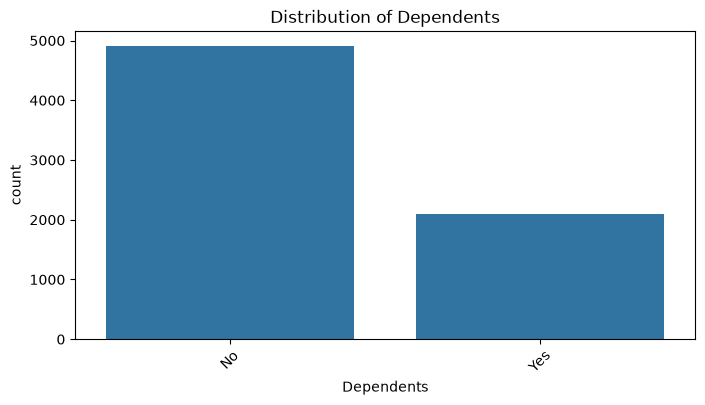

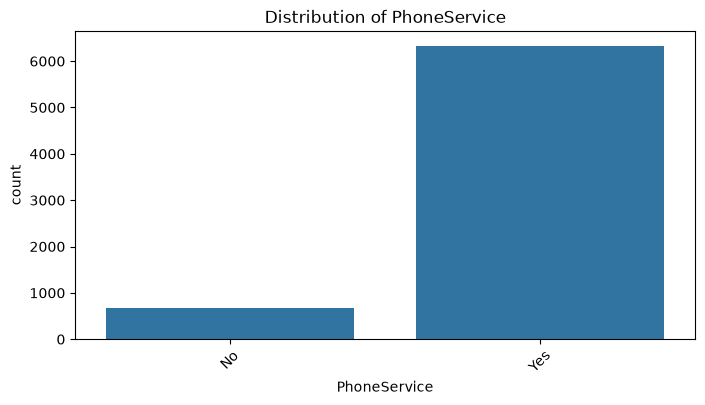

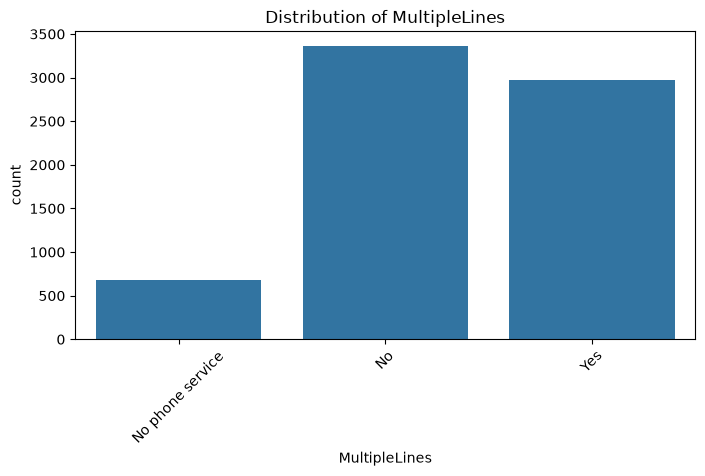

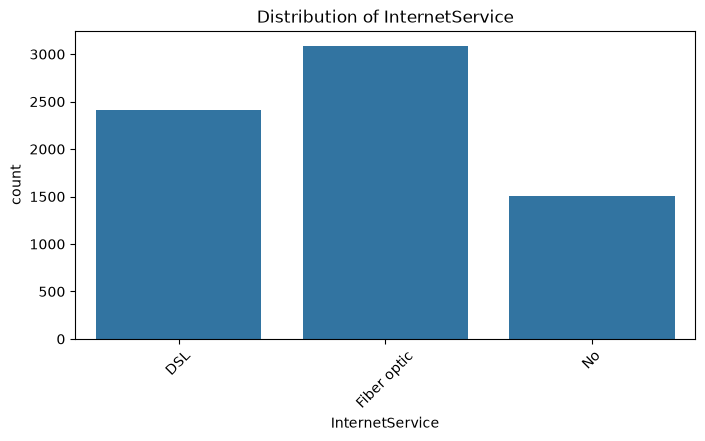

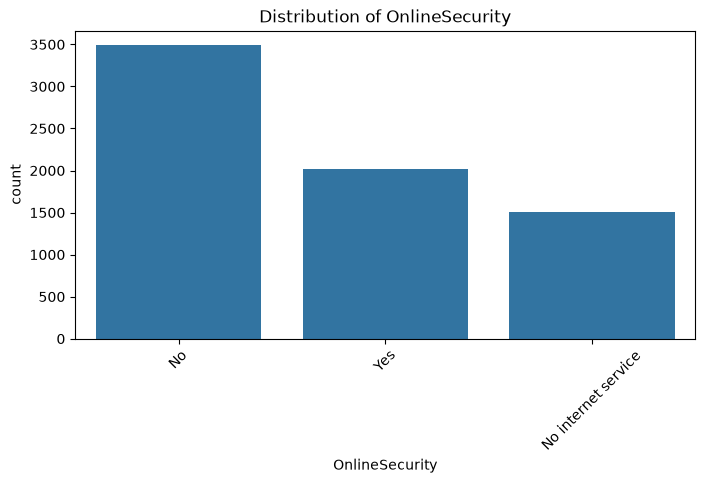

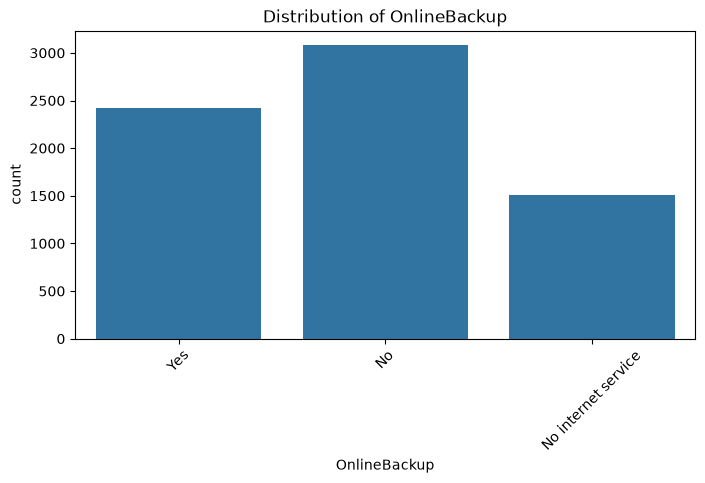

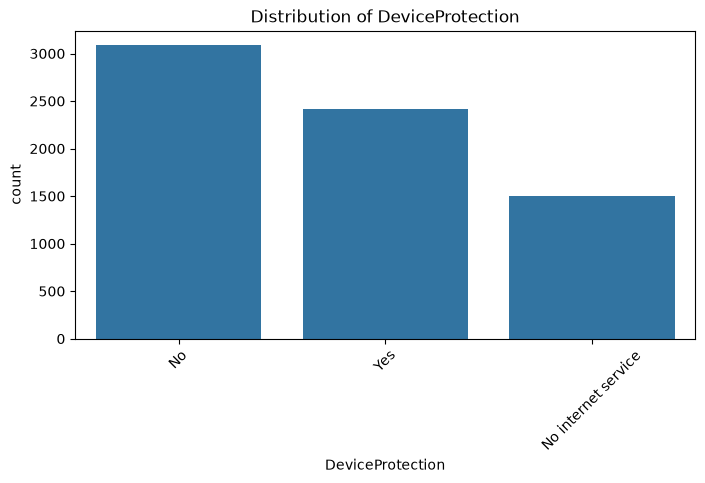

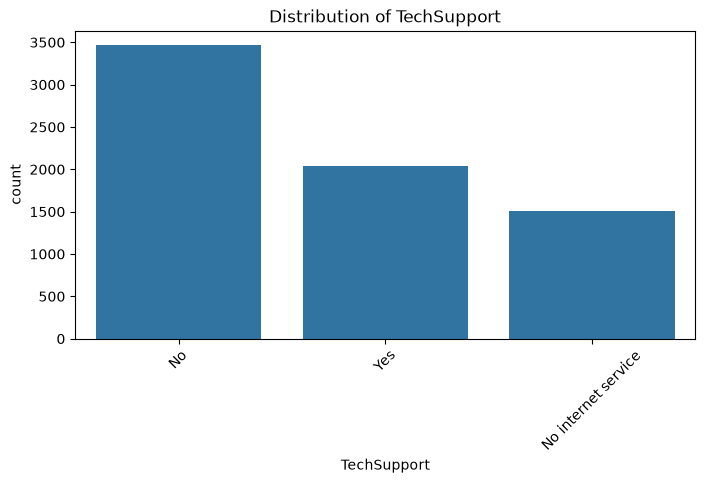

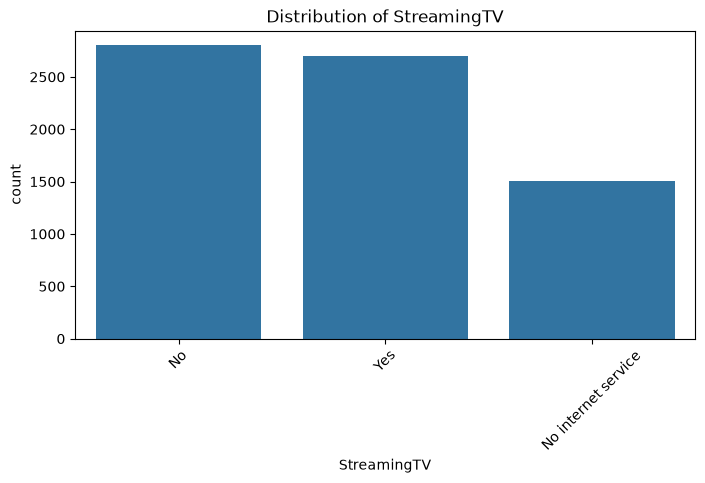

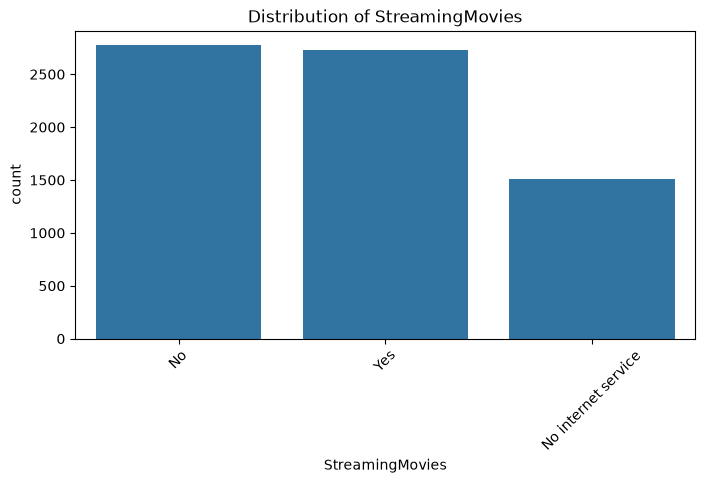

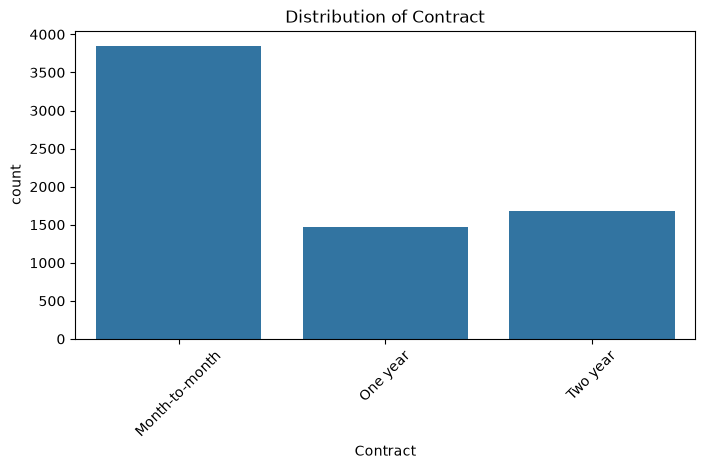

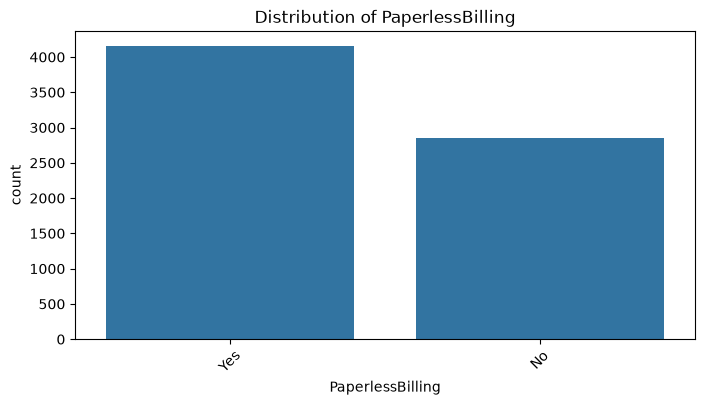

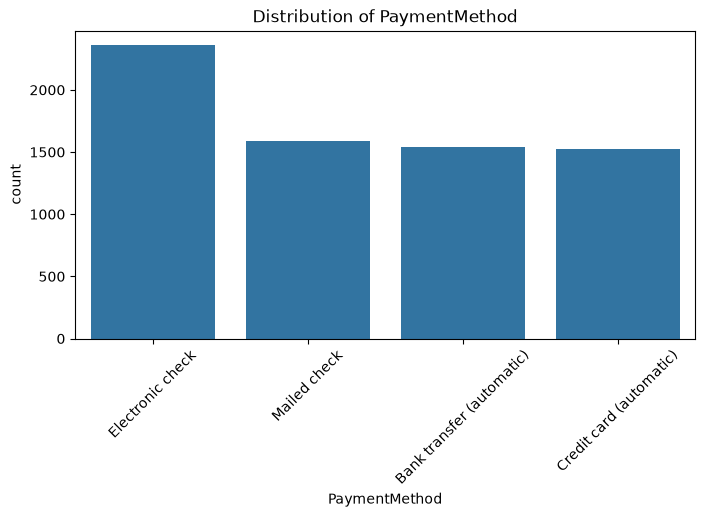

In [64]:
for col in categorical_features:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x=col)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)
    plt.show()

In [65]:
numeric_features = df.select_dtypes(include='number').columns.drop('Churn')
numeric_features

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')

In [66]:
df[numeric_features].describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7010.0,0.162767,0.369180,0.00,0.0000,0.000,0.0000,1.00
tenure,7010.0,32.520399,24.520441,1.00,9.0000,29.000,56.0000,72.00
MonthlyCharges,7010.0,64.888666,30.064769,18.25,35.7500,70.400,89.9000,118.75
TotalCharges,7010.0,2290.353388,2266.820832,18.80,408.3125,1403.875,3807.8375,8684.80


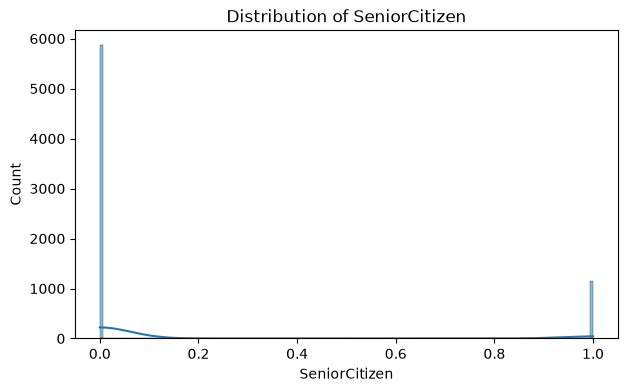

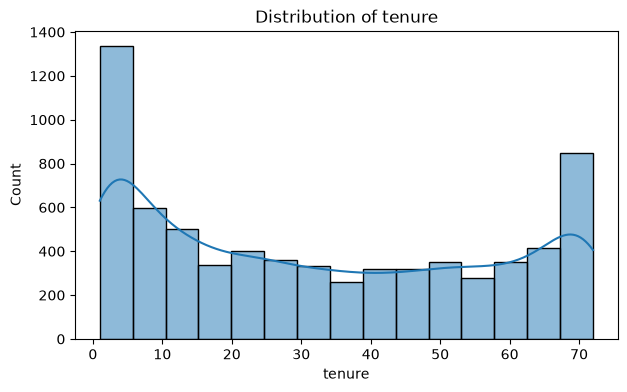

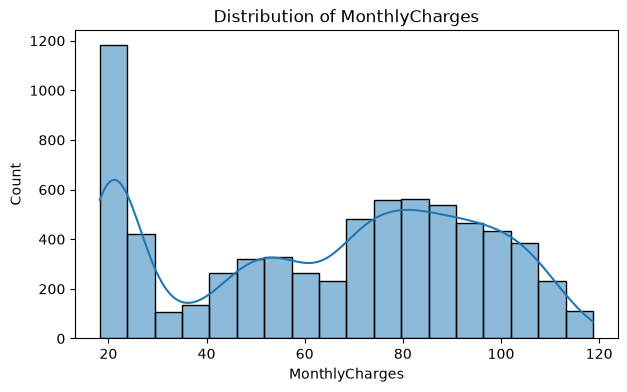

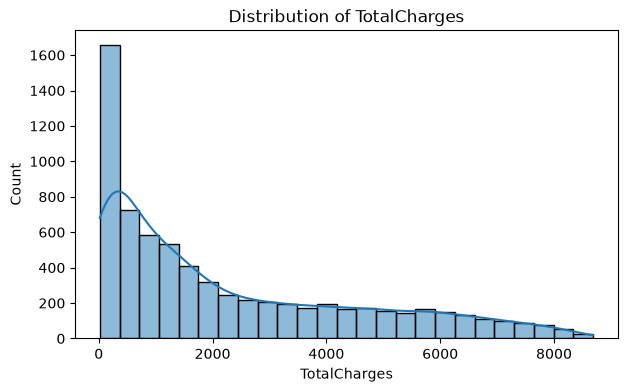

In [67]:
for col in numeric_features:
    plt.figure(figsize=(7, 4))
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

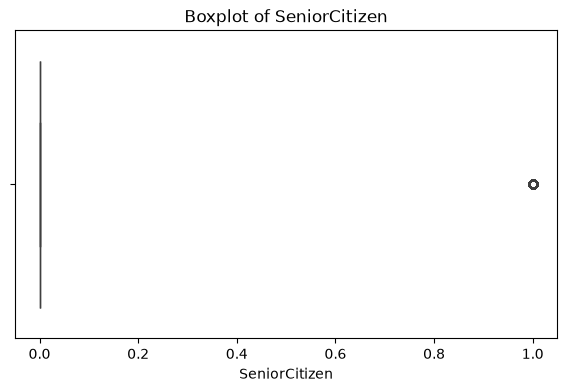

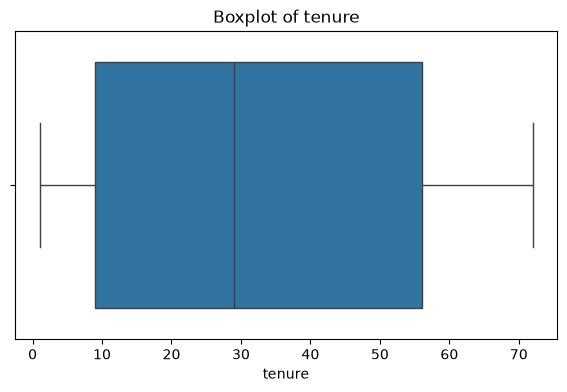

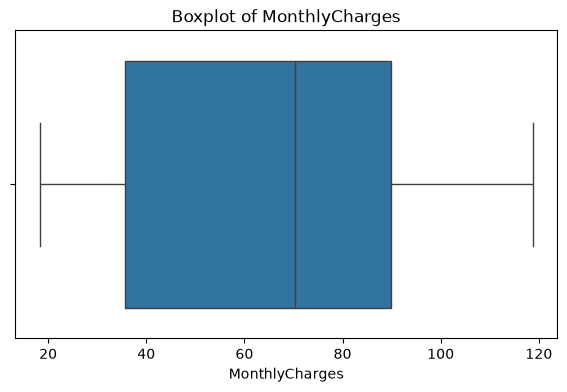

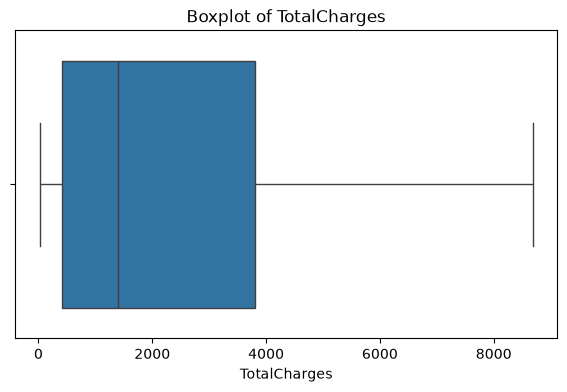

In [68]:
for col in numeric_features:
    plt.figure(figsize=(7, 4))
    sns.boxplot(data=df, x=col)
    plt.title(f"Boxplot of {col}")
    plt.show()

In [69]:
categorical_features = df.select_dtypes(include="object").columns

categorical_features

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

In [70]:
for col in categorical_features:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())


--- gender ---
gender
Male      3535
Female    3475
Name: count, dtype: int64

--- Partner ---
Partner
No     3617
Yes    3393
Name: count, dtype: int64

--- Dependents ---
Dependents
No     4911
Yes    2099
Name: count, dtype: int64

--- PhoneService ---
PhoneService
Yes    6330
No      680
Name: count, dtype: int64

--- MultipleLines ---
MultipleLines
No                  3363
Yes                 2967
No phone service     680
Name: count, dtype: int64

--- InternetService ---
InternetService
Fiber optic    3090
DSL            2414
No             1506
Name: count, dtype: int64

--- OnlineSecurity ---
OnlineSecurity
No                     3489
Yes                    2015
No internet service    1506
Name: count, dtype: int64

--- OnlineBackup ---
OnlineBackup
No                     3079
Yes                    2425
No internet service    1506
Name: count, dtype: int64

--- DeviceProtection ---
DeviceProtection
No                     3086
Yes                    2418
No internet service   

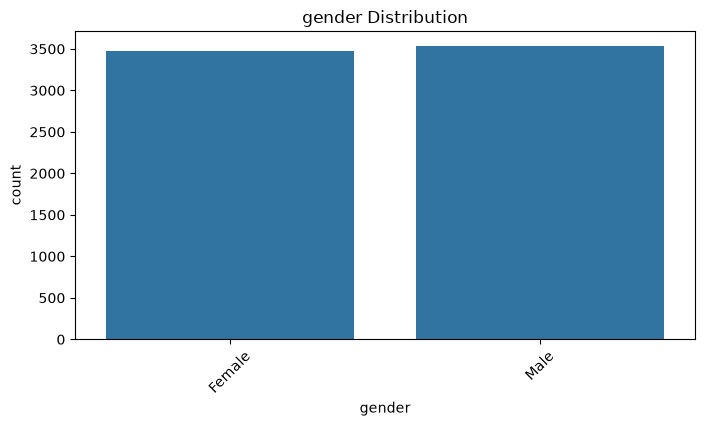

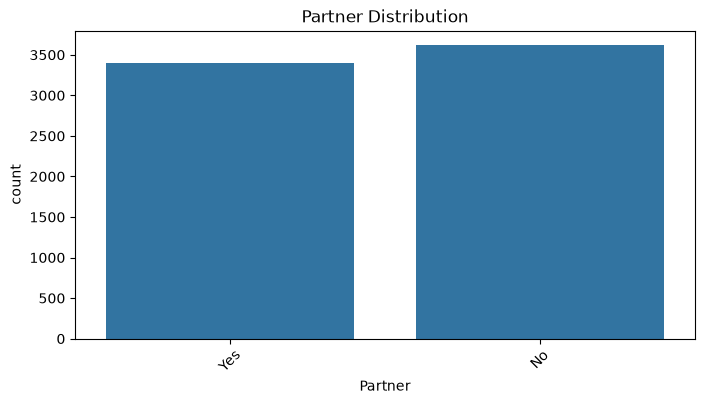

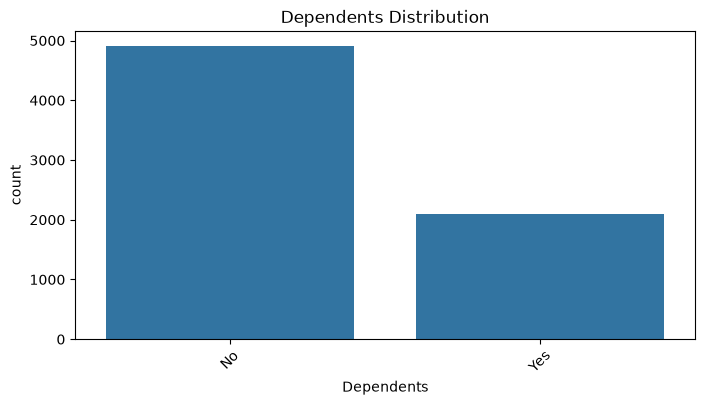

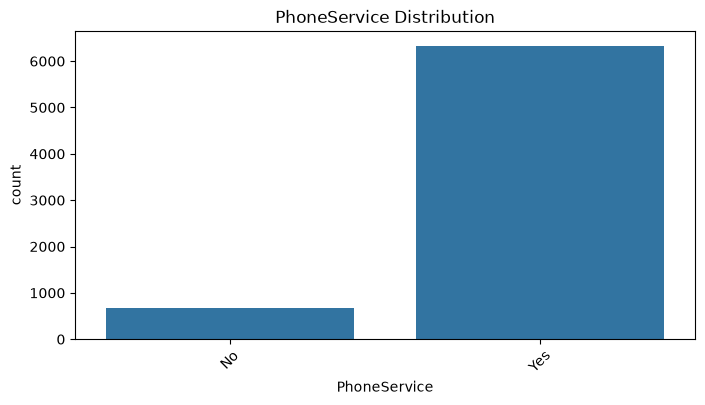

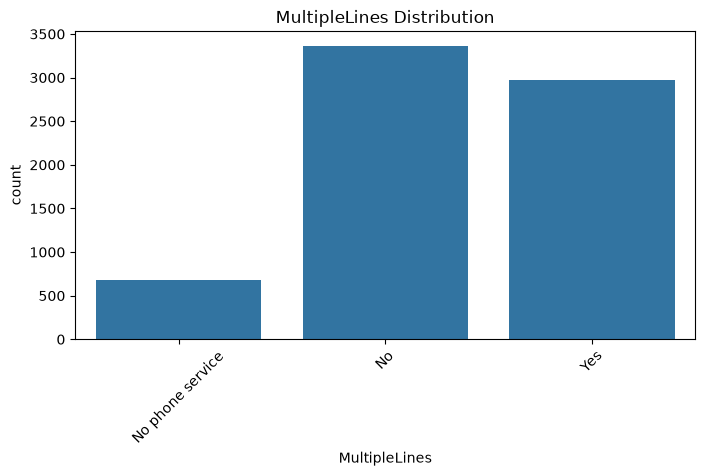

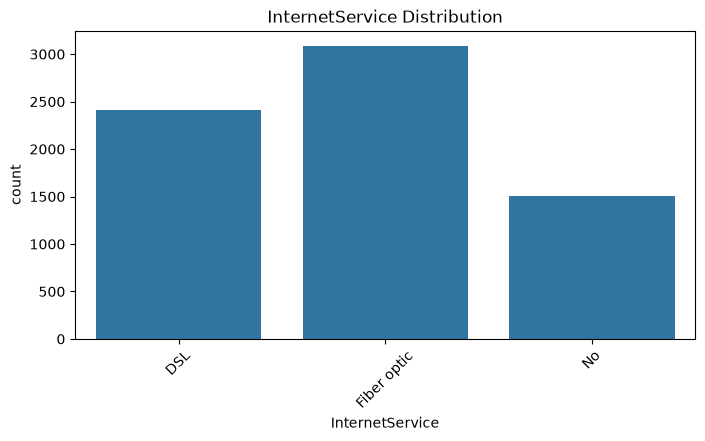

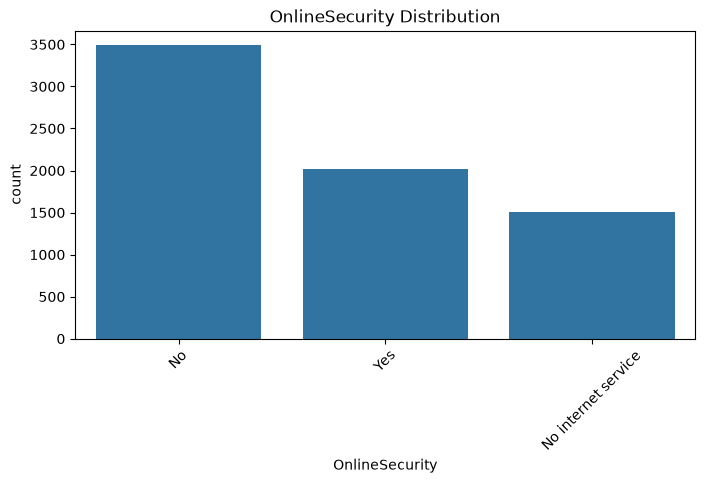

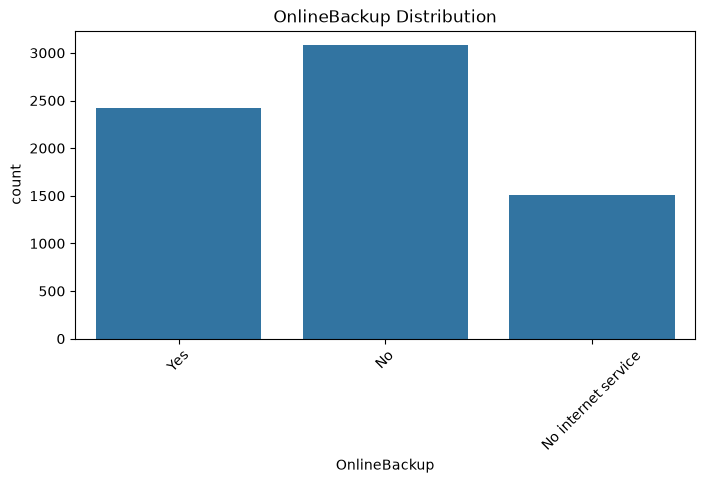

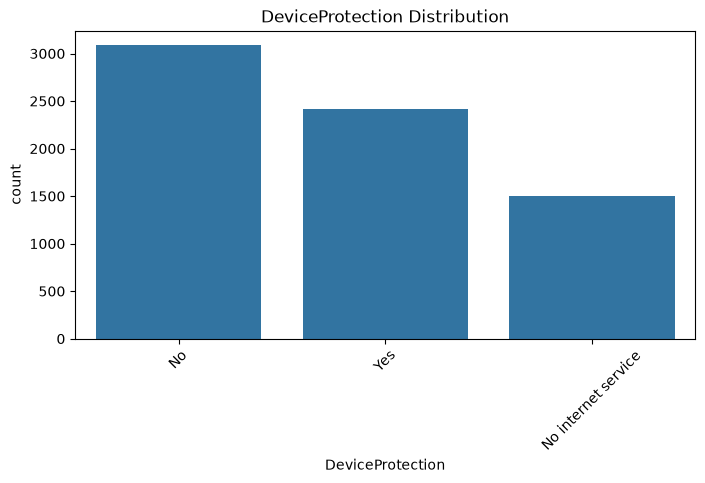

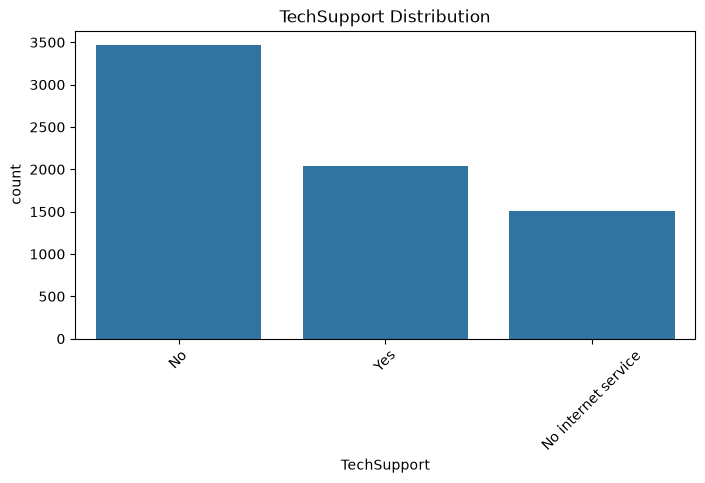

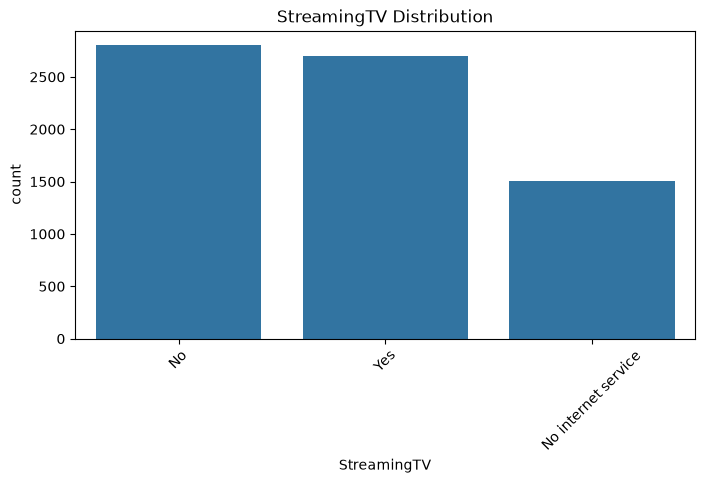

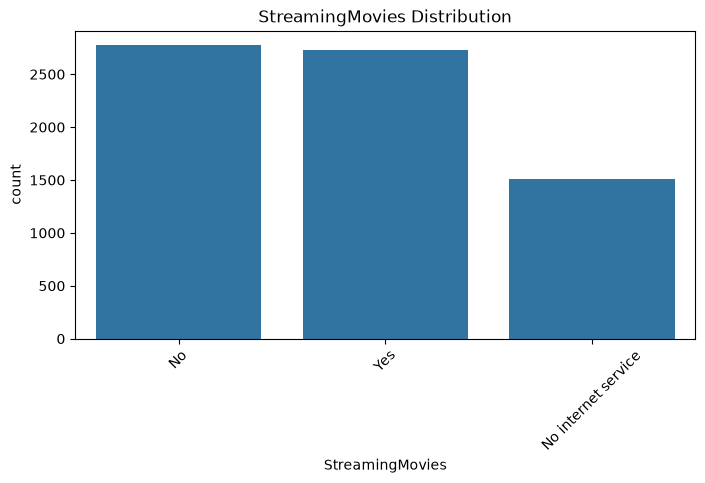

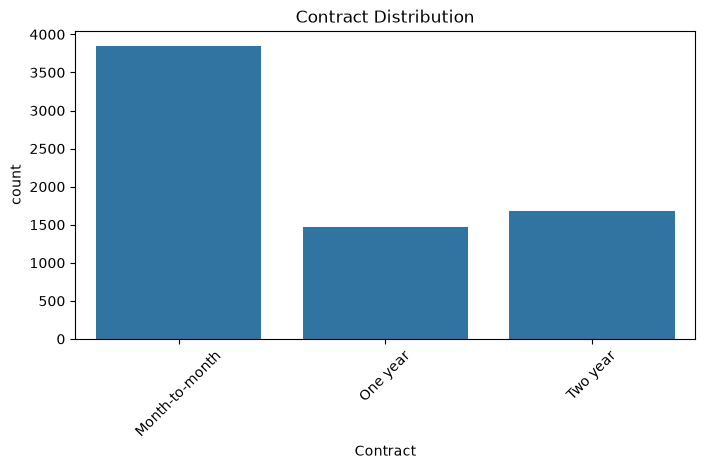

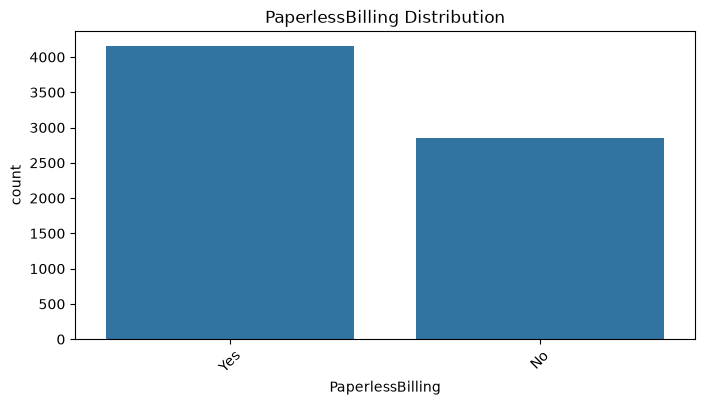

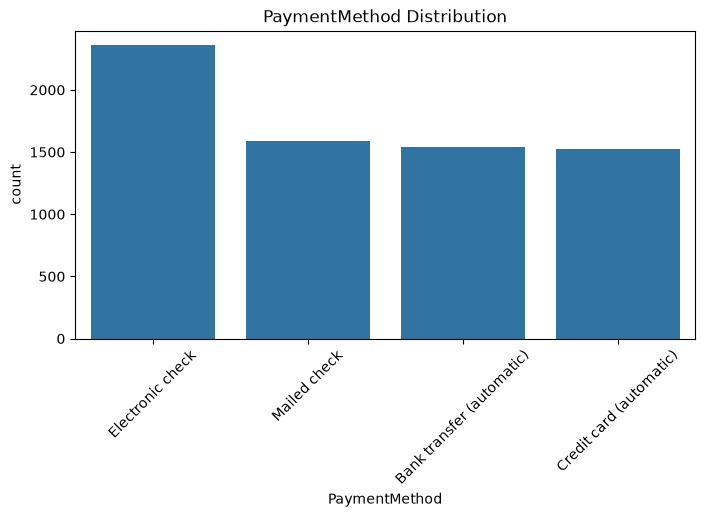

In [71]:
for col in categorical_features:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x=col)
    plt.title(f"{col} Distribution")
    plt.xticks(rotation=45)
    plt.show()

<h3 style="color:white; font-weight:bold">Step 5.4 — Features vs Churn</h3>

<h5 style="color:white; font-weight:bold">5.4.1 — Categorical Features vs Churn</h5>

In [72]:
for col in categorical_features:
    churn_rate = pd.crosstab(
        df[col],
        df["Churn"],
        normalize="index"
    ) * 100

    print(f"\n--- {col} ---")
    print(churn_rate)


--- gender ---
Churn           0          1
gender                      
Female  73.122302  26.877698
Male    73.889675  26.110325

--- Partner ---
Churn            0          1
Partner                      
No       67.155101  32.844899
Yes      80.282935  19.717065

--- Dependents ---
Churn               0          1
Dependents                      
No          68.825087  31.174913
Yes         84.468795  15.531205

--- PhoneService ---
Churn                 0          1
PhoneService                      
No            75.000000  25.000000
Yes           73.349131  26.650869

--- MultipleLines ---
Churn                     0          1
MultipleLines                         
No                75.111508  24.888492
No phone service  75.000000  25.000000
Yes               71.351534  28.648466

--- InternetService ---
Churn                    0          1
InternetService                      
DSL              81.068766  18.931234
Fiber optic      58.220065  41.779935
No               92.76

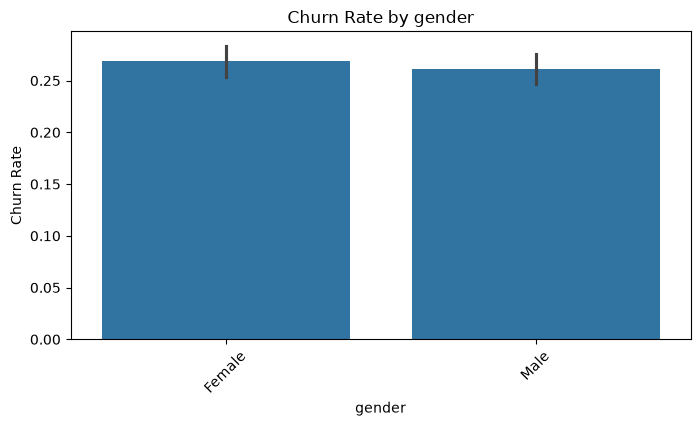

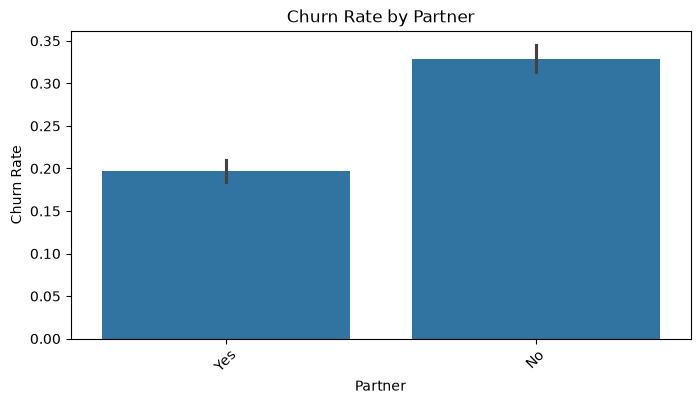

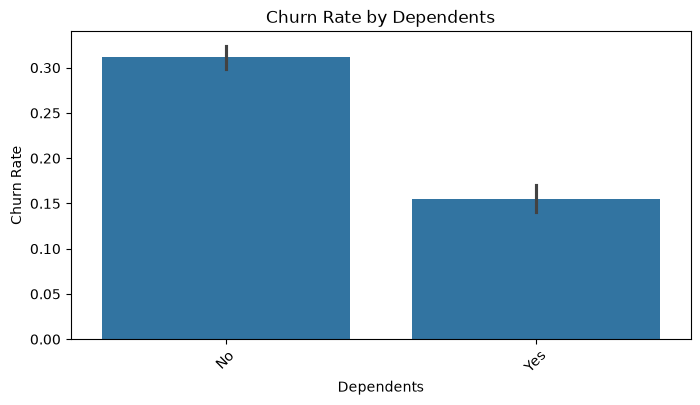

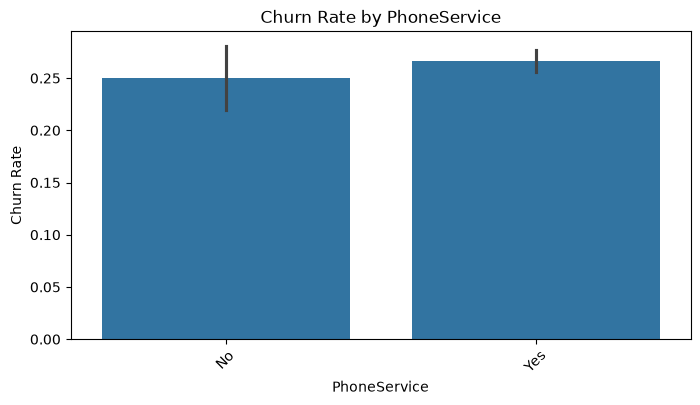

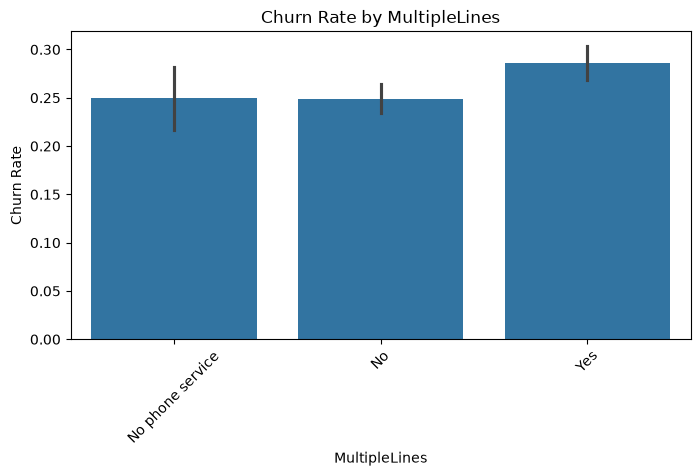

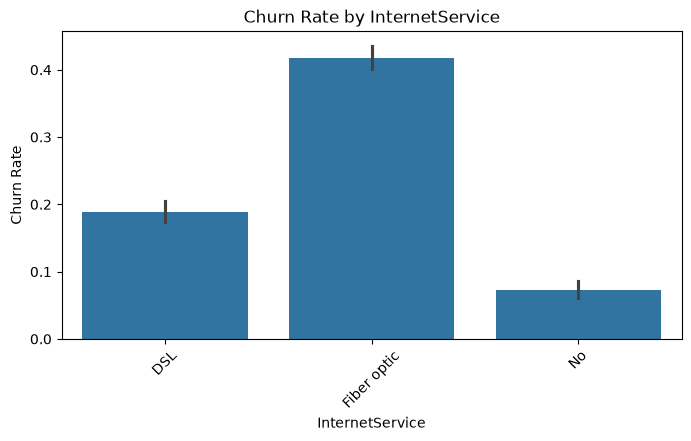

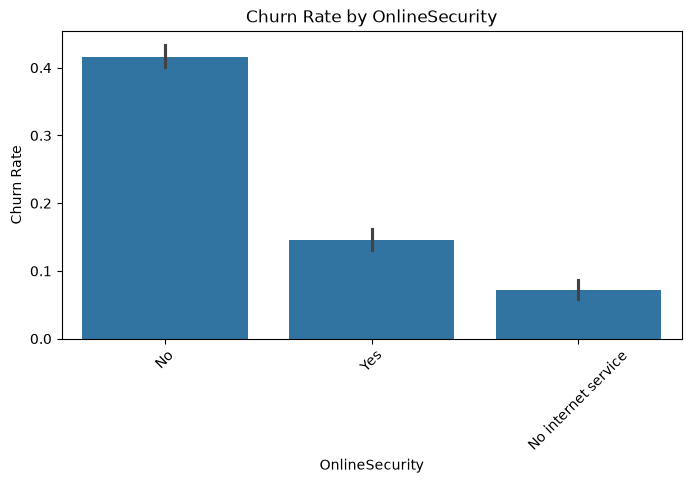

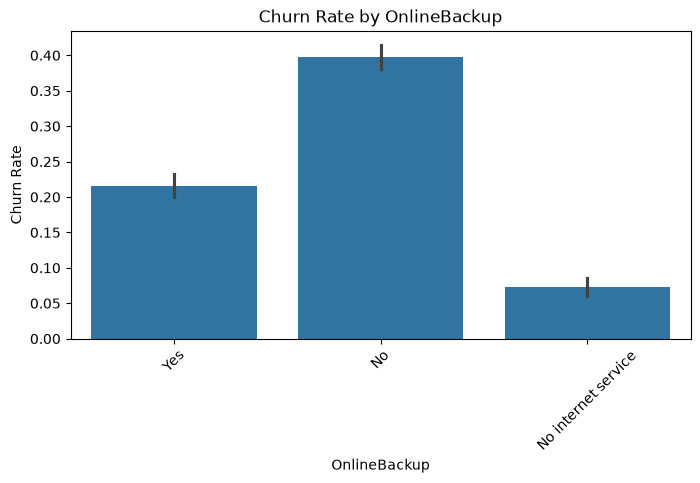

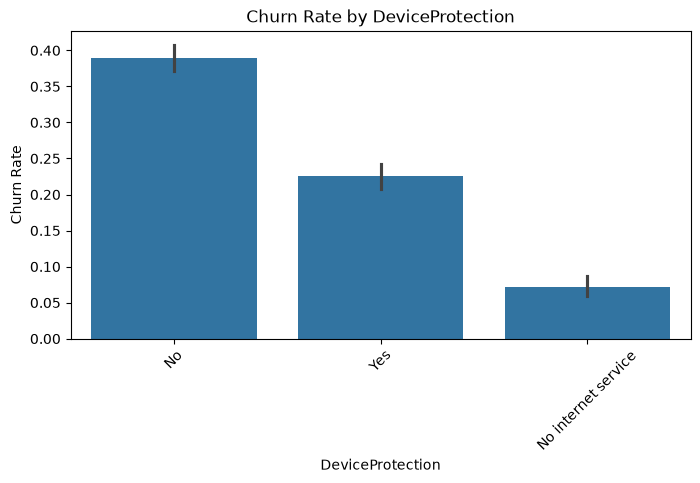

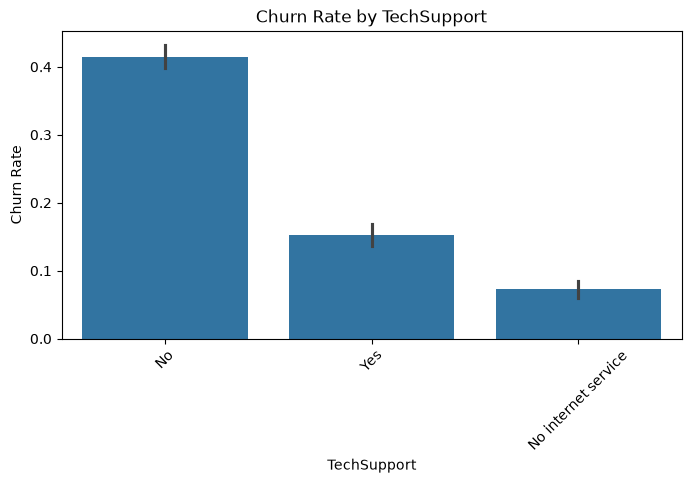

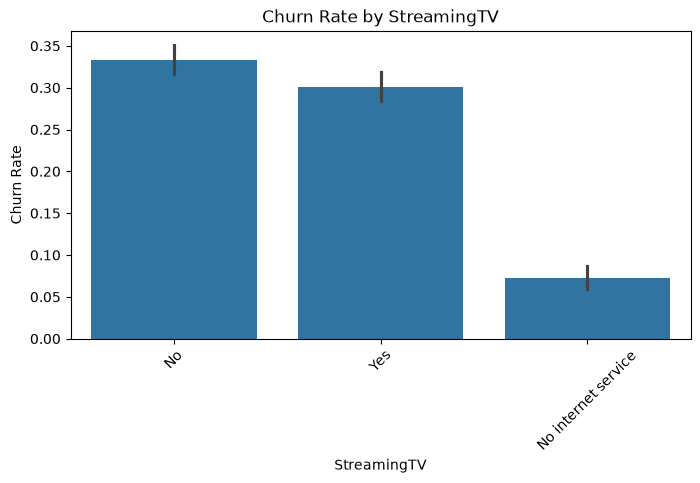

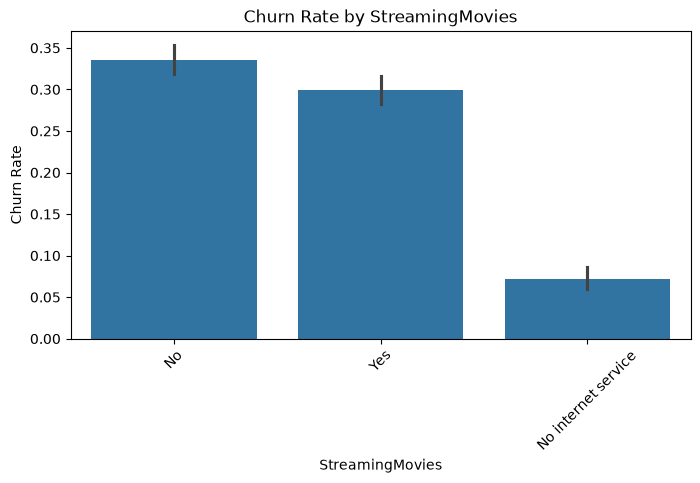

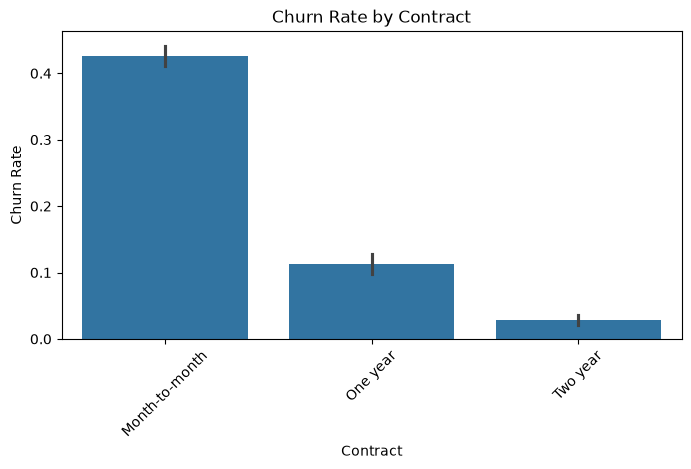

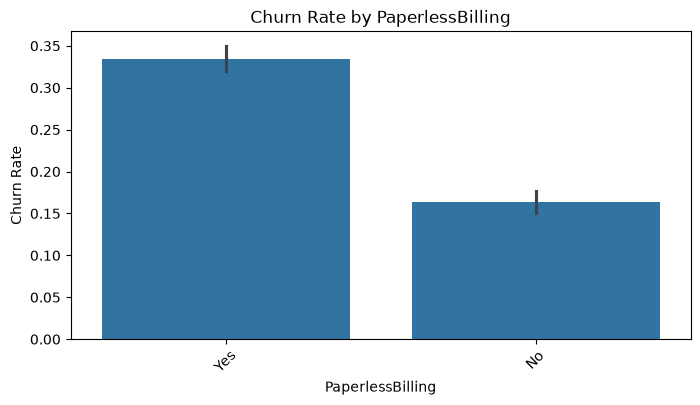

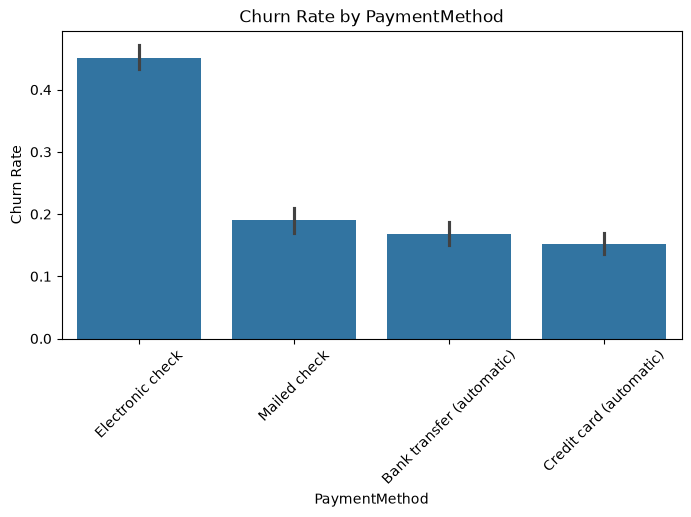

In [73]:
for col in categorical_features:
    plt.figure(figsize=(8, 4))

    sns.barplot(
        data=df,
        x=col,
        y="Churn"
    )

    plt.title(f"Churn Rate by {col}")
    plt.ylabel("Churn Rate")
    plt.xticks(rotation=45)
    plt.show()

<h5 style="color:white; font-weight:bold">5.4.2 — Numerical Features vs Churn</h5>


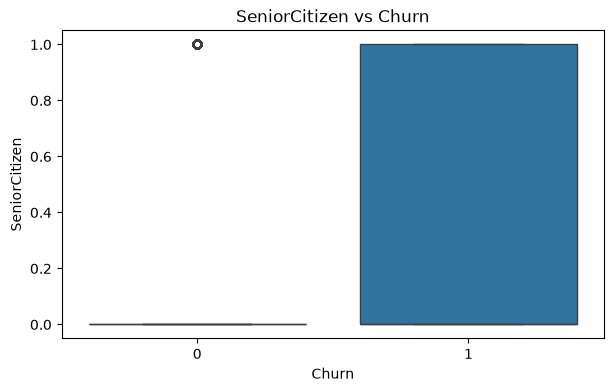

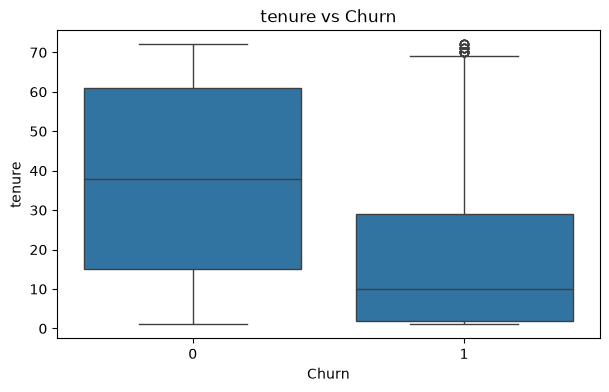

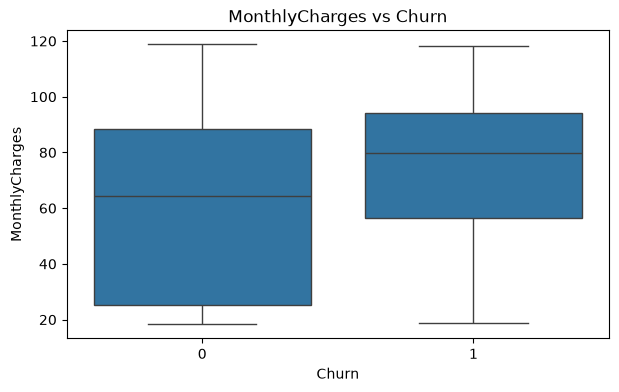

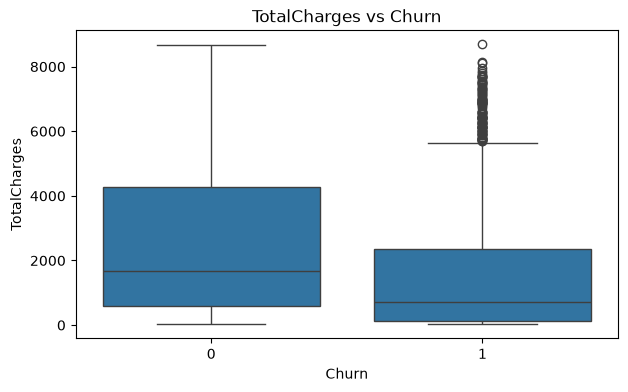

In [74]:
for col in numeric_features:
    plt.figure(figsize=(7, 4))

    sns.boxplot(
        data=df,
        x="Churn",
        y=col
    )

    plt.title(f"{col} vs Churn")
    plt.show()

<h5 style="color:white; font-weight:bold">5.4.3 — Correlation</h5>


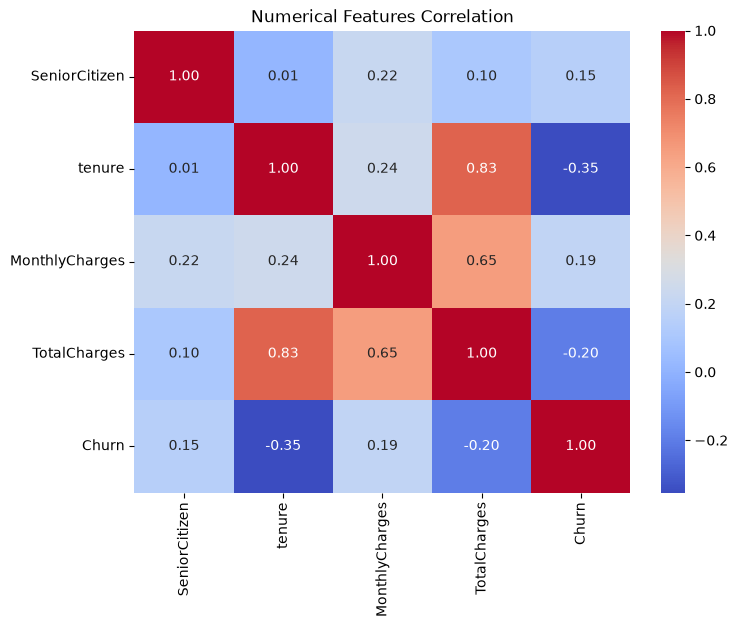

In [76]:
corr = df[numeric_features.tolist() + ["Churn"]].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Numerical Features Correlation")
plt.show()

<h1 style="color:orange; font-weight:bold">Step 6 — Train/Test Split</h1>


<h3 style="color:white; font-weight:bold">6.1 — X aur y Check</h3>


In [78]:
X = df.drop('Churn', axis=1)
y =  df['Churn']

In [83]:
X.shape, y.shape

((7010, 19), (7010,))

In [81]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [84]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (5608, 19)
X_test : (1402, 19)
y_train: (5608,)
y_test : (1402,)


In [86]:
print("Train:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTest:")
print(y_test.value_counts(normalize=True) * 100)

Train:
Churn
0    73.50214
1    26.49786
Name: proportion, dtype: float64

Test:
Churn
0    73.537803
1    26.462197
Name: proportion, dtype: float64


In [89]:
numeric_features = X_train.select_dtypes(include="number").columns
categorical_features = X_train.select_dtypes(include="object").columns

print("Numerical:", list(numeric_features))
print("Categorical:", list(categorical_features))

Numerical: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


<h1 style="color:orange; font-weight:bold">Step 7 — Preprocessing Pipeline</h1>


In [90]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [91]:
numerical_transformer = Pipeline(steps=[('scaler', StandardScaler())])

In [92]:
categorical_transformer = Pipeline(steps=[('encoder', OneHotEncoder(handle_unknown='ignore', drop="first"))])

In [93]:
preprocessor = ColumnTransformer(transformers=[('numerical', numerical_transformer, numeric_features),
                                               ('categorical', categorical_transformer, categorical_features)])

In [95]:
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

In [96]:
print("Before preprocessing:")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("\nAfter preprocessing:")
print("X_train:", X_train_transformed.shape)
print("X_test :", X_test_transformed.shape)

Before preprocessing:
X_train: (5608, 19)
X_test : (1402, 19)

After preprocessing:
X_train: (5608, 30)
X_test : (1402, 30)


In [97]:
from sklearn.linear_model import LogisticRegression

baseline_model = Pipeline(steps=[('preprocessor', preprocessor),
                                 ('model', LogisticRegression(max_iter=1000, random_state=42))])

In [99]:
baseline_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['gender','SeniorCitizen','Partner',...,'PaymentMethod','MonthlyCharges', 'TotalCharges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying `

In [101]:
y_pred = baseline_model.predict(X_test)
y_proba = baseline_model.predict_proba(X_test)[:, 1]

In [102]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_proba))

Accuracy : 0.8059914407988588
Precision: 0.6666666666666666
Recall   : 0.5336927223719676
F1 Score : 0.592814371257485
ROC-AUC  : 0.8472108569650799


In [103]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1031
           1       0.67      0.53      0.59       371

    accuracy                           0.81      1402
   macro avg       0.76      0.72      0.73      1402
weighted avg       0.80      0.81      0.80      1402



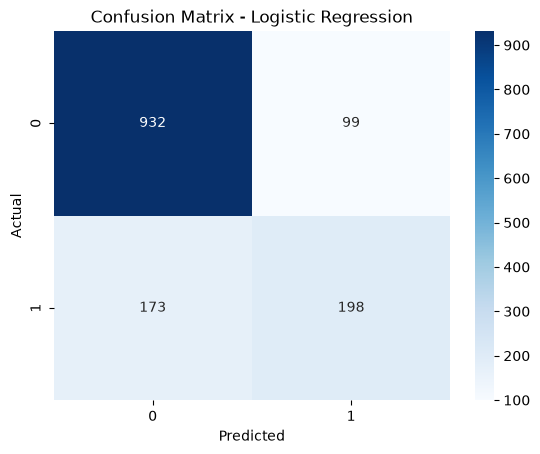

In [104]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

<h1 style="color:orange; font-weight:bold">Step 9 — Multiple Classification Models</h1>


In [107]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

models = {'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
          'Decision Tree Classifier': DecisionTreeClassifier(random_state=42),
          'Random Forest Classifier': RandomForestClassifier(random_state=42, n_jobs=-1),
          'GradientBoostClassifier': GradientBoostingClassifier(random_state=42)}

In [108]:
results = []
for name,model in models.items():
    pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                        ('model', model)])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba)
    })

In [109]:
results_df = pd.DataFrame(results)

results_df.sort_values(
    by="F1",
    ascending=False
).reset_index(drop=True)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.805991,0.666667,0.533693,0.592814,0.847211
1,GradientBoostClassifier,0.803852,0.675182,0.498652,0.573643,0.842598
2,Random Forest Classifier,0.789586,0.636691,0.477089,0.545455,0.818879
3,Decision Tree Classifier,0.724679,0.479339,0.469003,0.474114,0.643686


In [119]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid_lr = GridSearchCV(
    estimator=logistic_pipeline,
    param_grid=param_grid_lr,
    cv=cv,
    scoring="f1",
    n_jobs=-1,
    verbose=1,
    error_score="raise"
)

grid_lr.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': [0.01, 0.1, ...], 'model__class_weight': [None, 'balanced'], 'model__solver': ['liblinear', 'lbfgs']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"error_score error_score: 'raise' or numeric, default=np.nanValue to assign to the score if an error occurs in estimator fitting.If set to 'raise', the error is raised. If a numeric value is given,FitFailedWarning is raised. This parameter does not affect the refitstep, which will always raise the error.",'raise'
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on thi

In [120]:
print("Best Parameters:")
print(grid_lr.best_params_)

print("\nBest CV F1:")
print(grid_lr.best_score_)

Best Parameters:
{'model__C': 0.1, 'model__class_weight': 'balanced', 'model__solver': 'lbfgs'}

Best CV F1:
0.6293747145558493


In [121]:
best_lr = grid_lr.best_estimator_

y_pred_lr = best_lr.predict(X_test)
y_proba_lr = best_lr.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1 Score :", f1_score(y_test, y_pred_lr))
print("ROC-AUC  :", roc_auc_score(y_test, y_proba_lr))

Accuracy : 0.7475035663338089
Precision: 0.5152603231597845
Recall   : 0.7735849056603774
F1 Score : 0.6185344827586207
ROC-AUC  : 0.8461572649483269


In [122]:
dt_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                              ('model', DecisionTreeClassifier(random_state=42))])
param_grid_dt = {
    "model__max_depth": [3, 5, 7, 10, None],
    "model__min_samples_split": [2, 5, 10, 20],
    "model__min_samples_leaf": [1, 2, 5, 10],
    "model__class_weight": [None, "balanced"]
}

In [123]:
grid_dt = GridSearchCV(
    estimator=dt_pipeline,
    param_grid=param_grid_dt,
    cv=cv,
    scoring="f1",
    n_jobs=-1,
    verbose=1,
    error_score="raise"
)
grid_dt.fit(X_train, y_train)


Fitting 5 folds for each of 160 candidates, totalling 800 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__class_weight': [None, 'balanced'], 'model__max_depth': [3, 5, ...], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"error_score error_score: 'raise' or numeric, default=np.nanValue to assign to the score if an error occurs in estimator fitting.If set to 'raise', the error is raised. If a numeric value is given,FitFailedWarning is raised. This parameter does not affect the refitstep, which will always raise the error.",'raise'
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute an

In [124]:
print("Best Parameters:")
print(grid_dt.best_params_)

print("\nBest CV F1:")
print(grid_dt.best_score_)

Best Parameters:
{'model__class_weight': 'balanced', 'model__max_depth': 5, 'model__min_samples_leaf': 10, 'model__min_samples_split': 2}

Best CV F1:
0.6125116966321185


In [125]:
best_dt = grid_dt.best_estimator_

y_pred_dt = best_dt.predict(X_test)
y_proba_dt = best_dt.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall   :", recall_score(y_test, y_pred_dt))
print("F1 Score :", f1_score(y_test, y_pred_dt))
print("ROC-AUC  :", roc_auc_score(y_test, y_proba_dt))

Accuracy : 0.7296718972895863
Precision: 0.49328859060402686
Recall   : 0.7924528301886793
F1 Score : 0.6080661840744571
ROC-AUC  : 0.8277899927059014


In [126]:
rf_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                              ('model', RandomForestClassifier(random_state=42, n_jobs=-1))])
param_grid_rf = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 5, 10, 15],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 5],
    "model__class_weight": [None, "balanced"]
}

In [129]:
grid_rf = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid_rf,
    cv=cv,
    scoring="f1",
    n_jobs=-1,
    verbose=1,
    error_score="raise"
)
grid_rf.fit(X_train, y_train)

Fitting 5 folds for each of 144 candidates, totalling 720 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__class_weight': [None, 'balanced'], 'model__max_depth': [None, 5, ...], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"error_score error_score: 'raise' or numeric, default=np.nanValue to assign to the score if an error occurs in estimator fitting.If set to 'raise', the error is raised. If a numeric value is given,FitFailedWarning is raised. This parameter does not affect the refitstep, which will always raise the error.",'raise'
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attr

In [130]:
print("Best Parameters:")
print(grid_rf.best_params_)

print("\nBest CV F1:")
print(grid_rf.best_score_)

Best Parameters:
{'model__class_weight': 'balanced', 'model__max_depth': 10, 'model__min_samples_leaf': 1, 'model__min_samples_split': 10, 'model__n_estimators': 100}

Best CV F1:
0.6377705253962906


In [131]:
best_rf = grid_rf.best_estimator_

y_pred_rf = best_rf.predict(X_test)
y_proba_rf = best_rf.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))
print("ROC-AUC  :", roc_auc_score(y_test, y_proba_rf))

Accuracy : 0.7631954350927247
Precision: 0.5368620037807184
Recall   : 0.7654986522911051
F1 Score : 0.6311111111111111
ROC-AUC  : 0.8433389716628191


In [132]:
gb_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                              ('model'), GradientBoostingClassifier(random_state=42)])
param_grid_gb = {
    "model__n_estimators": [100, 200],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__max_depth": [2, 3, 5],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 5]
}

In [138]:
gb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingClassifier(random_state=42))
])

grid_gb = GridSearchCV(
    gb_pipeline,
    param_grid=param_grid_gb,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1,
    error_score="raise"
)

grid_gb.fit(X_train, y_train)

Fitting 5 folds for each of 162 candidates, totalling 810 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__learning_rate': [0.01, 0.05, ...], 'model__max_depth': [2, 3, ...], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"error_score error_score: 'raise' or numeric, default=np.nanValue to assign to the score if an error occurs in estimator fitting.If set to 'raise', the error is raised. If a numeric value is given,FitFailedWarning is raised. This parameter does not affect the refitstep, which will always raise the error.",'raise'
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``

In [140]:
print(grid_gb.best_params_)
print(grid_gb.best_score_)

{'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__min_samples_leaf': 1, 'model__min_samples_split': 5, 'model__n_estimators': 200}
0.8031390676455482


In [141]:
best_gb = grid_gb.best_estimator_

y_pred_gb = best_gb.predict(X_test)
y_proba_gb = best_gb.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test, y_pred_gb))
print("Precision:", precision_score(y_test, y_pred_gb))
print("Recall   :", recall_score(y_test, y_pred_gb))
print("F1 Score :", f1_score(y_test, y_pred_gb))
print("ROC-AUC  :", roc_auc_score(y_test, y_proba_gb))

Accuracy : 0.8059914407988588
Precision: 0.68
Recall   : 0.5040431266846361
F1 Score : 0.5789473684210527
ROC-AUC  : 0.8425899540131921


In [143]:
import xgboost as xgb

print(xgb.__version__)

xgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", xgb.XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=42,
            n_jobs=-1
        ))
    ]
)

param_grid_xgb = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [3, 5],
    "model__learning_rate": [0.03, 0.1],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0]
}

grid_xgb = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=param_grid_xgb,
    cv=cv,
    scoring="f1",
    n_jobs=-1,
    verbose=1,
    error_score="raise"
)

grid_xgb.fit(X_train, y_train)

3.4.1
Fitting 5 folds for each of 32 candidates, totalling 160 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__colsample_bytree': [0.8, 1.0], 'model__learning_rate': [0.03, 0.1], 'model__max_depth': [3, 5], 'model__n_estimators': [100, 200], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"error_score error_score: 'raise' or numeric, default=np.nanValue to assign to the score if an error occurs in estimator fitting.If set to 'raise', the error is raised. If a numeric value is given,FitFailedWarning is raised. This parameter does not affect the refitstep, which will always raise the error.",'raise'
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits u

In [144]:
print("Best Parameters:")
print(grid_xgb.best_params_)

print("\nBest CV F1:")
print(grid_xgb.best_score_)

best_xgb = grid_xgb.best_estimator_

y_pred_xgb = best_xgb.predict(X_test)
y_proba_xgb = best_xgb.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall   :", recall_score(y_test, y_pred_xgb))
print("F1 Score :", f1_score(y_test, y_pred_xgb))
print("ROC-AUC  :", roc_auc_score(y_test, y_proba_xgb))

Best Parameters:
{'model__colsample_bytree': 0.8, 'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 100, 'model__subsample': 0.8}

Best CV F1:
0.5860603459969242
Accuracy : 0.8067047075606276
Precision: 0.6712328767123288
Recall   : 0.5283018867924528
F1 Score : 0.5912518853695324
ROC-AUC  : 0.8440997539875713


<h1 style="color:orange; font-weight:bold">Step 13 — Cross-Validation Stability Analysis</h1>


In [145]:
from sklearn.model_selection import cross_validate

cv_results_rf = cross_validate(
    grid_rf.best_estimator_,
    X_train,
    y_train,
    cv=cv,
    scoring={
        "accuracy": "accuracy",
        "precision": "precision",
        "recall": "recall",
        "f1": "f1",
        "roc_auc": "roc_auc"
    },
    n_jobs=-1
)

for metric in ["accuracy", "precision", "recall", "f1", "roc_auc"]:
    scores = cv_results_rf[f"test_{metric}"]

    print(f"\n{metric.upper()}")
    print("Fold scores:", scores)
    print("Mean:", scores.mean())
    print("Std :", scores.std())


ACCURACY
Fold scores: [0.76381462 0.75846702 0.78253119 0.76895629 0.75914362]
Mean: 0.7665825490037066
Std : 0.008818784215986466

PRECISION
Fold scores: [0.53571429 0.52801724 0.56818182 0.54822335 0.53161593]
Mean: 0.5423505241175539
Std : 0.014604520608484255

RECALL
Fold scores: [0.80808081 0.82491582 0.75503356 0.72727273 0.76430976]
Mean: 0.7759225363252209
Std : 0.03570015859696495

F1
Fold scores: [0.6442953  0.64388962 0.64841499 0.6251809  0.62707182]
Mean: 0.6377705253962906
Std : 0.00965693029653568

ROC_AUC
Fold scores: [0.85013978 0.85777778 0.84167916 0.83927054 0.83974249]
Mean: 0.8457219483350393
Std : 0.007191370968475658


In [146]:
cv_results_gb = cross_validate(
    grid_gb.best_estimator_,
    X_train,
    y_train,
    cv=cv,
    scoring={
        "accuracy": "accuracy",
        "precision": "precision",
        "recall": "recall",
        "f1": "f1",
        "roc_auc": "roc_auc"
    },
    n_jobs=-1
)

for metric in ["accuracy", "precision", "recall", "f1", "roc_auc"]:
    scores = cv_results_gb[f"test_{metric}"]

    print(f"\n{metric.upper()}")
    print("Fold scores:", scores)
    print("Mean:", scores.mean())
    print("Std :", scores.std())


ACCURACY
Fold scores: [0.79500891 0.82531194 0.78431373 0.80017841 0.79661017]
Mean: 0.8002846325457439
Std : 0.013585156020944048

PRECISION
Fold scores: [0.64255319 0.68100358 0.63461538 0.69945355 0.64197531]
Mean: 0.659920204177736
Std : 0.025578744285505346

RECALL
Fold scores: [0.50841751 0.63973064 0.44295302 0.43097643 0.52525253]
Mean: 0.5094660249022664
Std : 0.07457047541008117

F1
Fold scores: [0.56766917 0.65972222 0.52173913 0.53333333 0.57777778]
Mean: 0.5720483273400893
Std : 0.0485151141267302

ROC_AUC
Fold scores: [0.84821753 0.85978574 0.8448292  0.83952592 0.84593917]
Mean: 0.8476595107781357
Std : 0.006700480929472101


In [147]:
final_models = {
    "Logistic Regression": grid_lr.best_estimator_,
    "Decision Tree": grid_dt.best_estimator_,
    "Random Forest": grid_rf.best_estimator_,
    "Gradient Boosting": grid_gb.best_estimator_,
    "XGBoost": grid_xgb.best_estimator_
}

final_results = []

for name, model in final_models.items():

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    final_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba)
    })

final_results_df = pd.DataFrame(final_results)

final_results_df.sort_values(
    by="F1",
    ascending=False
).reset_index(drop=True)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Random Forest,0.763195,0.536862,0.765499,0.631111,0.843339
1,Logistic Regression,0.747504,0.515260,0.773585,0.618534,0.846157
2,Decision Tree,0.729672,0.493289,0.792453,0.608066,0.827790
3,XGBoost,0.806705,0.671233,0.528302,0.591252,0.844100
4,Gradient Boosting,0.805991,0.680000,0.504043,0.578947,0.842590


<h1 style="color:orange; font-weight:bold">Step 15 — Error Analysis</h1>

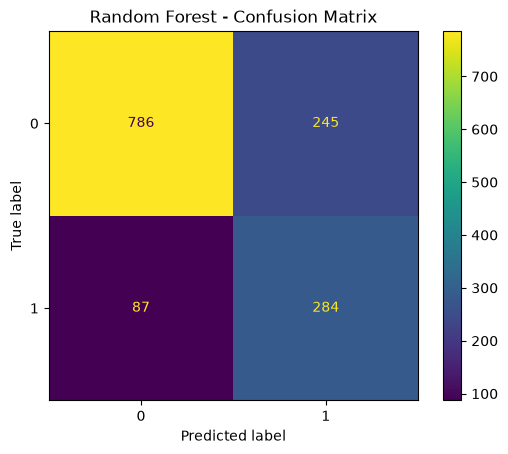

In [148]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf
)

plt.title("Random Forest - Confusion Matrix")
plt.show()

In [152]:
tn, fp, fn, tp = confusion_matrix(
    y_test,
    y_pred_rf
).ravel()

print("True Negative :", tn)
print("False Positive:", fp)
print("False Negative:", fn)
print("True Positive :", tp)

print("False Positive Rate:",
      fp / (fp + tn))

print("False Negative Rate:",
      fn / (fn + tp))

print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=["Stayed", "Churned"]
    )
)

True Negative : 786
False Positive: 245
False Negative: 87
True Positive : 284
False Positive Rate: 0.2376333656644035
False Negative Rate: 0.23450134770889489
              precision    recall  f1-score   support

      Stayed       0.90      0.76      0.83      1031
     Churned       0.54      0.77      0.63       371

    accuracy                           0.76      1402
   macro avg       0.72      0.76      0.73      1402
weighted avg       0.80      0.76      0.77      1402



<h1 style="color:orange; font-weight:bold">Step 16 — Threshold Analysis</h1>

In [153]:
y_proba_rf[:10]

array([0.69396429, 0.05381054, 0.27149979, 0.54032433, 0.58083031,
       0.55143622, 0.17752611, 0.26151035, 0.40995707, 0.30116757])

In [154]:
thresholds = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]

threshold_results = []

for threshold in thresholds:

    y_pred_threshold = (y_proba_rf >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_test, y_pred_threshold),
        "Recall": recall_score(y_test, y_pred_threshold),
        "F1": f1_score(y_test, y_pred_threshold)
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df

,Threshold,Precision,Recall,F1
0,0.30,0.436601,0.900270,0.588028
1,0.35,0.459770,0.862534,0.599813
2,0.40,0.488189,0.835580,0.616302
3,0.45,0.512953,0.800539,0.625263
4,0.50,0.536862,0.765499,0.631111
5,0.55,0.556723,0.714286,0.625738
6,0.60,0.577465,0.663073,0.617315
7,0.65,0.618785,0.603774,0.611187
8,0.70,0.670068,0.530997,0.592481


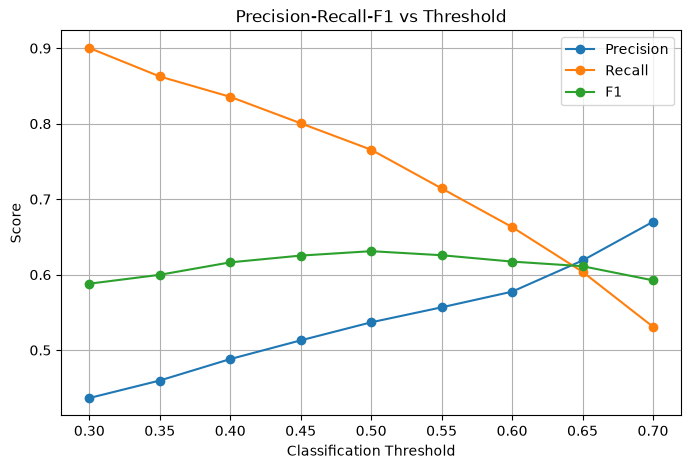

In [155]:
plt.figure(figsize=(8, 5))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1"],
    marker="o",
    label="F1"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Precision-Recall-F1 vs Threshold")
plt.legend()
plt.grid()
plt.show()

In [157]:
feature_names = (
    best_rf
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

feature_names

array(['numerical__SeniorCitizen', 'numerical__tenure',
       'numerical__MonthlyCharges', 'numerical__TotalCharges',
       'categorical__gender_Male', 'categorical__Partner_Yes',
       'categorical__Dependents_Yes', 'categorical__PhoneService_Yes',
       'categorical__MultipleLines_No phone service',
       'categorical__MultipleLines_Yes',
       'categorical__InternetService_Fiber optic',
       'categorical__InternetService_No',
       'categorical__OnlineSecurity_No internet service',
       'categorical__OnlineSecurity_Yes',
       'categorical__OnlineBackup_No internet service',
       'categorical__OnlineBackup_Yes',
       'categorical__DeviceProtection_No internet service',
       'categorical__DeviceProtection_Yes',
       'categorical__TechSupport_No internet service',
       'categorical__TechSupport_Yes',
       'categorical__StreamingTV_No internet service',
       'categorical__StreamingTV_Yes',
       'categorical__StreamingMovies_No internet service',
       'cate

In [158]:
importances = (
    best_rf
    .named_steps["model"]
    .feature_importances_
)

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
)

feature_importance_df.head(15)

,Feature,Importance
1,numerical__tenure,0.164186
3,numerical__TotalCharges,0.138782
25,categorical__Contract_Two year,0.108470
2,numerical__MonthlyCharges,0.097264
10,categorical__InternetService_Fiber optic,0.083477
28,categorical__PaymentMethod_Electronic check,0.055070
24,categorical__Contract_One year,0.046377
13,categorical__OnlineSecurity_Yes,0.034906
19,categorical__TechSupport_Yes,0.026929
16,categorical__DeviceProtection_No internet service,0.019047


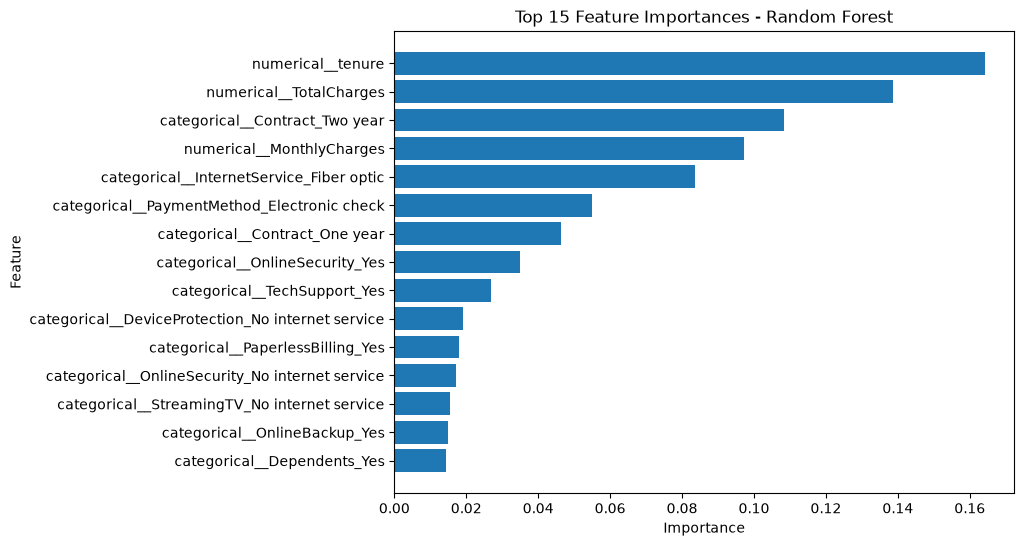

In [159]:
top_features = feature_importance_df.head(15).sort_values(
    by="Importance"
)

plt.figure(figsize=(8, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances - Random Forest")

plt.show()

In [161]:
import joblib

joblib.dump(
    best_rf,
    "../models/random_forest_churn_pipeline.pkl"
)

['../models/random_forest_churn_pipeline.pkl']

In [162]:
import os

os.path.exists(
    "../models/random_forest_churn_pipeline.pkl"
)

True

In [163]:
loaded_model = joblib.load(
    "../models/random_forest_churn_pipeline.pkl"
)

loaded_predictions = loaded_model.predict(X_test)

print(
    f"Loaded model accuracy: "
    f"{accuracy_score(y_test, loaded_predictions):.4f}"
)

Loaded model accuracy: 0.7632
